# jval_lab — validating interventional unmixing on the jval_* worlds

Executes section 7 of the v2 handoff. Nothing here re-simulates: the worlds
exist, and every arm below is either an analysis window or a Jacobian
rebuilt from a few hundred zero-duration solves.

Order is dependency order, and it is deliberate:

| § | What | Why before the next one |
|---|---|---|
| 1 | discovery + arm labels | know what was actually built |
| 2 | the three per-world assertions (7.7) | a truncated front invalidates every window below |
| 3 | window step counts | `pre` and `post` must be equal-length or the two estimators have different variance |
| 4 | **ground-truth audit** | P3/P4 are claims about the *estimator*; they can only be scored if the invariance and the signed change hold in the truth first |
| 5 | one world end to end | catch a unit or naming error on 1 world, not 41 |
| 6 | full sweep | |
| 7–12 | M1, gain, M2, pair-level, beta, coupling | |
| 13 | the P1–P7 scoreboard (7.8) | |

Two things are fixed here rather than upstream, both from handoff §8:
`J.unmix` forwards `rcond` to `pinv` (`unmix_demands` drops it), and
`J.state_map` remaps regimes per window (the commissioning
`consumption_map` is wrong for the drifter after onset).

In [1]:
import sys, pathlib, copy
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import wntr, yaml

HERE = pathlib.Path.cwd().resolve()
PROJ = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)
for p in (PROJ / "src", PROJ / "notebooks", PROJ, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
import sensitivity_probe as S

In [2]:
# =====================================================================
# 0. setup
# =====================================================================
import sys, pathlib, json, warnings
import numpy as np, pandas as pd, yaml
from scipy import stats as sps
import matplotlib.pyplot as plt

PROJ = pathlib.Path.home() / "USPy/10_Mestrado/fedWater"      # <-- adjust
sys.path.insert(0, str(PROJ / "notebooks"))

import placement_poc as P
import sensitivity_probe as S
import jval_engine as J

OUT = PROJ / "data/08_reporting/jval"; OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

PLACEMENT   = "variance"     # the deployment recommendation (handoff 5.1)
MAIN_ARM    = "J_pre"        # commissioning-time J -- the Q2 protagonist
DELTA_FRAC  = 0.5            # reciprocity-calibrated step (handoff 4)
RCOND       = 1e-3
ARMS        = J.ARMS_DEFAULT           # J_pre / J_post / J_pre_wpost / J_perm
# J.ARMS_ALL adds "J_inp" -- the network's own base demands, i.e. the old
# J_flat. Opt in only after SS5 shows that operating point is feasible.

J.api_report()               # fails loudly if a borrowed signature drifted
J.selftest()                 # measurands checked against known answers

           module               name                                                                                                                                               signature
sensitivity_probe      flat_baseline                    (wn, anchor_scale: 'float' = 1.0, demand_model: 'str' = 'DD', min_pressure: 'float | None' = None, demand_multiplier: 'float' = 1.0)
sensitivity_probe perturbation_sweep                                                                 (wn_flat, deltas, nodes=None, verbose=False, drop_infeasible: 'bool' = True) -> 'tuple'
sensitivity_probe           jacobian                                                                (sweep: 'pd.DataFrame', quantity='pressure', delta=None, targets=None) -> 'pd.DataFrame'
sensitivity_probe  district_jacobian (sweep: 'pd.DataFrame', districts: 'dict', sensors: 'list', quantity='flowrate', delta=None, node_weights: 'pd.Series | None' = None) -> 'pd.DataFrame'
sensitivity_probe      unmix_demands                   

True

## 1. Discovery and arm labels

Arms are inferred from the world spec rather than read back from
`experiments_jval.yml`, because several cells are deliberate **cache hits**
shared between studies — `jval_coupling`'s baseline arm and `jval_beta`'s
`beta=0.35` cell *are* `jval_s1_oddone` worlds. `arms` therefore lists every
study a world serves; `arm` is its primary identity.

Check the counts against the design: s1_oddone 15, s2_split 15, income 6,
beta 3 (one of which is an s1 cache hit), coupling 4 (two cached),
s1_equalised 5 if the optional arm was run.

In [3]:
# =====================================================================
# 1. discover the jval worlds
# =====================================================================
IDX = J.jval_index(PROJ, n_months=48)
print(f"{len(IDX)} worlds at n_months=48 | usable {int(IDX.usable.sum())}")

show = [c for c in ("sim_hash", "arm", "arms", "variant", "sim_seed", "beta",
                    "consumption_map", "drift_district", "drift_to_land_use",
                    "drift_to_income", "status", "usable", "missing")
        if c in IDX.columns]
display(IDX[show])

print("\nby arm:")
print(IDX.groupby("arm").agg(n=("sim_hash", "size"),
                             usable=("usable", "sum"),
                             seeds=("sim_seed", "nunique")).to_string())
print("\nEXPECTED  s1_oddone 15 | s2_split 15 | income 6 | beta 2-3 |"
      " coupling_isolated 2 | s1_equalised 0 or 5")

45 worlds at n_months=48 | usable 45


,sim_hash,arm,arms,variant,sim_seed,beta,consumption_map,drift_district,drift_to_land_use,drift_to_income,status,usable,missing
0,2f848af2d6ac,beta,beta,baseline,42,0.00,LR_LR_LR_LR_LI,District_D,industrial,low,ok,True,
1,4ffa4bda4b5c,beta,beta,baseline,42,1.00,LR_LR_LR_LR_LI,District_D,industrial,low,ok,True,
2,b472a1a6af0b,coupling_isolated,coupling_isolated,isolated,42,0.35,LR_LR_LR_LR_LI,District_A,industrial,low,ok,True,
3,adce256d7a30,coupling_isolated,coupling_isolated,isolated,42,0.35,LR_LR_LR_LR_LI,District_E,residential,low,ok,True,
4,262eba17b212,income,income,baseline,42,0.35,LR_LR_LR_LR_HR,District_C,residential,high,ok,True,
5,e1e2fa18f0b3,income,income,baseline,43,0.35,LR_LR_LR_LR_HR,District_C,residential,high,ok,True,
6,cb4df28db5fe,income,income,baseline,44,0.35,LR_LR_LR_LR_HR,District_C,residential,high,ok,True,
7,163515cc1a8a,income,income,baseline,42,0.35,LR_LR_LR_LR_HR,District_E,residential,low,ok,True,
8,616a7f27accb,income,income,baseline,43,0.35,LR_LR_LR_LR_HR,District_E,residential,low,ok,True,
9,f8fb7bd1c240,income,income,baseline,44,0.35,LR_LR_LR_LR_HR,District_E,residential,low,ok,True,



by arm:
                    n  usable  seeds
arm                                 
beta                2       2      1
coupling_isolated   2       2      1
income              6       6      3
s1_oddone          20      20      3
s2_split           15      15      3

EXPECTED  s1_oddone 15 | s2_split 15 | income 6 | beta 2-3 | coupling_isolated 2 | s1_equalised 0 or 5


## 2. The three per-world assertions (handoff 7.7)

`front_complete` · `clears_post` · `pre_clean`. Recorded as rows, not raised,
so a failure is *documented and excluded* rather than aborting the sweep —
these are the three lines that would have caught the `resolution_probe`
truncation (5 of 24 nodes converted, ramp clamped to 29 of 42 days) on the
day it happened.

The surviving set is then **pinned to an explicit `sim_hash` list on disk**
(handoff 6.9). `.head(20)` on a growing pool already cost this project one
headline; every table below is reconstructible from `pinned_worlds.csv`.

In [4]:
# =====================================================================
# 2. gate every world, then pin the survivors
# =====================================================================
def _districts():
    for c in (PROJ / "data/01_raw/districts_graeme.yml",
              pathlib.Path(IDX.iloc[0]["dir"]) / "clone/data/01_raw/districts_graeme.yml"):
        if c.exists():
            return yaml.safe_load(c.read_text())
    return P.load_world(IDX.iloc[0]["dir"])["districts"]   # last resort
DISTRICTS = _districts()
DS = sorted(DISTRICTS["districts"])
print({d: len(DISTRICTS["districts"][d]) for d in DS})

GATES = J.gate_table(IDX, DISTRICTS)
display(GATES[["sim_hash", "arm", "tgt", "n_nodes", "n_converted", "onset",
               "last", "span", "front_complete", "clears_post", "pre_clean",
               "ok", "why"]])

bad = GATES[~GATES.ok]
print(f"\n{len(bad)} world(s) fail the gate")
if len(bad):
    print(bad.groupby("why").size().to_string())

WORLDS = J.pin(IDX, GATES, path=OUT / "pinned_worlds.csv")
print(f"\npinned {len(WORLDS)} worlds -> {OUT/'pinned_worlds.csv'}")
print(WORLDS.groupby("arm").size().to_string())

{'District_A': 12, 'District_B': 29, 'District_C': 18, 'District_D': 24, 'District_E': 30}


,sim_hash,arm,tgt,n_nodes,n_converted,onset,last,span,front_complete,clears_post,pre_clean,ok,why
0,2f848af2d6ac,beta,District_D,24,24,6.0,23.0,17.0,True,True,True,True,
1,4ffa4bda4b5c,beta,District_D,24,24,6.0,23.0,17.0,True,True,True,True,
2,b472a1a6af0b,coupling_isolated,District_A,12,12,6.0,14.0,8.0,True,True,True,True,
3,adce256d7a30,coupling_isolated,District_E,30,30,6.0,26.0,20.0,True,True,True,True,
4,262eba17b212,income,District_C,18,18,6.0,16.0,10.0,True,True,True,True,
5,e1e2fa18f0b3,income,District_C,18,18,6.0,19.0,13.0,True,True,True,True,
6,cb4df28db5fe,income,District_C,18,18,6.0,19.0,13.0,True,True,True,True,
7,163515cc1a8a,income,District_E,30,30,6.0,26.0,20.0,True,True,True,True,
8,616a7f27accb,income,District_E,30,30,6.0,26.0,20.0,True,True,True,True,
9,f8fb7bd1c240,income,District_E,30,30,6.0,24.0,18.0,True,True,True,True,



0 world(s) fail the gate

pinned 45 worlds -> C:\Users\arthu\USPy\10_Mestrado\fedWater\data\08_reporting\jval\pinned_worlds.csv
arm
beta                  2
coupling_isolated     2
income                6
s1_oddone            20
s2_split             15


## 3. Windows

`pre` 0–5 · `transition` 6–35 · `post` 36–41 · spare 42–47.

Two properties are load-bearing and both are asserted:

* **equal length** (4 320 steps each) — otherwise the pre and post
  correlation estimators do not have the same variance and a pre→post
  difference is partly an estimator artifact;
* **`36 ≡ 0 (mod 12)`** — pre and post cover the same calendar months, so
  the seasonal cycle *cancels* rather than merely matching.

In [5]:
# =====================================================================
# 3. window sanity, one world per arm
# =====================================================================
rows = []
for arm, g in WORLDS.groupby("arm"):
    w = g.iloc[0]
    dem = pd.read_parquet(pathlib.Path(w["dir"]) / J.PATHS["demand"])
    mo = J.month_vector({"steps_day": 24}, dem, len(dem))
    r = J.window_report(J.window_masks(mo))
    rows.append(dict(arm=arm, sim_hash=w["sim_hash"], n_rows=len(dem),
                     months=int(mo.max()) + 1, **r))
WR = pd.DataFrame(rows)
display(WR)
assert WR.pre_eq_post.all(), "pre and post differ in length"
assert (WR.pre == 4320).all(), WR[["arm", "pre", "post"]]
print("windows OK | 36 % 12 ==", 36 % 12, "-> seasonal cycle cancels")

,arm,sim_hash,n_rows,months,pre,transition,post,pre_eq_post
0,beta,2f848af2d6ac,34560,48,4320,21600,4320,True
1,coupling_isolated,b472a1a6af0b,34560,48,4320,21600,4320,True
2,income,262eba17b212,34560,48,4320,21600,4320,True
3,s1_oddone,74e5d158e6e7,34560,48,4320,21600,4320,True
4,s2_split,321c58788a66,34560,48,4320,21600,4320,True


windows OK | 36 % 12 == 0 -> seasonal cycle cancels


## 4. Ground-truth audit — before any estimator is scored

P3 (invariance) and P4 (signed change) are claims about the **estimator**.
They are only scoreable if the corresponding statements hold in the
**truth**, and "by construction" is a claim about the simulator, not a
measurement — the demand series carries seasonal and stochastic variation
on top of the construction.

So measure it. Demand only, no hydraulics, seconds per world.

* `d_true` on non-drifter pairs sets the **empirical noise floor** for P3.
  If it is materially above 0.02, the P3 threshold comes from here instead.
* Sign agreement on drifter pairs is the **ceiling** for P4. If the truth
  itself does not move in the predicted direction, a P4 failure indicts the
  prediction (or `state_map`), not the unmixing.

In [6]:
# =====================================================================
# 4. does the construction actually hold in the ground truth?
# =====================================================================
TA = J.truth_audit(WORLDS, DISTRICTS)
DT = J.delta_rho(TA, method="truth", placement="truth")

nd = DT[~DT.involves_drifter]
sd = DT[DT.predicted != 0]
print(f"non-drifter pairs   n={len(nd):4d}  mean |d rho_true| = "
      f"{nd.d_true.abs().mean():.4f}   p95 = {nd.d_true.abs().quantile(.95):.4f}")
print(f"drifter pairs       n={len(sd):4d}  sign agreement    = "
      f"{(np.sign(sd.d_true)==sd.predicted).mean():.3f}")
print(f"                          mean d_true | predicted +1 : "
      f"{sd.loc[sd.predicted==1,'d_true'].mean():+.3f}")
print(f"                          mean d_true | predicted -1 : "
      f"{sd.loc[sd.predicted==-1,'d_true'].mean():+.3f}")

FLOOR = float(max(0.02, nd.d_true.abs().quantile(.95)))
print(f"\nP3 threshold adopted: {FLOOR:.4f}")

def sign_hit(g, col):
    q = g[g.predicted != 0]
    return np.nan if not len(q) else float((np.sign(q[col]) == q.predicted).mean())

print("\nper arm:")
display(pd.DataFrame([dict(
    arm=a, n=len(g),
    invariance_true=g.loc[~g.involves_drifter, "d_true"].abs().mean(),
    signed_true=sign_hit(g, "d_true"))
    for a, g in DT.groupby("arm_study")]).round(4))

# the S1 gap statistic in the truth, pre vs post
for win in ("pre", "post"):
    q = TA[TA.window == win]
    g = pd.Series({h: (x.loc[x.state_a == x.state_b, "rho_true"].mean() -
                       x.loc[x.state_a != x.state_b, "rho_true"].mean())
                   for h, x in q.groupby("sim_hash")})
    print(f"G_true[{win:10s}] mean {g.mean():+.3f}  sd {g.std():.3f}  "
          f"(n={g.notna().sum()} worlds)")

  10/45
  20/45
  30/45
  40/45
non-drifter pairs   n= 270  mean |d rho_true| = 0.0012   p95 = 0.0041
drifter pairs       n= 156  sign agreement    = 1.000
                          mean d_true | predicted +1 : +0.720
                          mean d_true | predicted -1 : -0.720

P3 threshold adopted: 0.0200

per arm:


,arm,n,invariance_true,signed_true
0,beta,20,0.0012,1.0
1,coupling_isolated,20,0.0007,1.0
2,income,60,0.0004,NaN
3,s1_oddone,200,0.0012,1.0
4,s2_split,150,0.0016,1.0


G_true[pre       ] mean +0.719  sd 0.001  (n=39 worlds)
G_true[post      ] mean +0.720  sd 0.001  (n=34 worlds)


## 5. One world, end to end

Run the whole chain on a single `s1_oddone` world before spending 41. The
things that break here are unit and naming errors, and the diagnostic table
below is designed to show them:

**`probe_diag` runs first, and it is not optional.** `perturbation_sweep`
drops infeasible solves *silently*, so an operating point outside the
network's envelope yields an empty sweep, an empty Jacobian, and then a
zero-size reduction deep inside `unmixing_quality` — a long way from the
cause. The table below asks the question directly: what total demand does
each candidate operating point imply, and is it feasible?

Read the `x_pre_mean` column. On these worlds `wn_variant` carries base
demands around **5× the pre-window mean**, so `inp_base` is infeasible while
every world-anchored point is fine. That ratio is a *finding* about which
operating point the section-5 Jacobian was measured at, not something to
scale away: it says the `.inp`-anchored Jacobian and the worlds do not live
at the same operating point. Hence `J_inp` is opt-in and `MAIN_ARM` is
`J_pre`.

Then the walkthrough. `op_total` is in m³/s; `demand_series` is L/s injected
as a pattern on a 1 L/s base, so a factor-of-10³ discrepancy means the
conversion is wrong. `J_perm` should share `J_pre`'s conditioning almost
exactly — it is the same matrix with its district columns shuffled — and
still collapse. If it recovers anything, the result is not coming from the
Jacobian.

In [7]:
# =====================================================================
# 5. single-world walkthrough
# =====================================================================
w0 = WORLDS[WORLDS.arm == "s1_oddone"].iloc[0]
print(w0[[c for c in ("sim_hash", "consumption_map", "drift_district",
                      "drift_to_land_use", "sim_seed", "beta", "variant")
          if c in w0.index]].to_string(), "\n")

art0 = P.load_world(w0["dir"])
pl0 = J.placements(art0, names=("variance", "boundary", "manual"))
print({k: {d: v[d] for d in sorted(v)} for k, v in pl0.items()}, "\n")

# --- operating points and feasibility, BEFORE any Jacobian is trusted ---
dem0 = pd.read_parquet(pathlib.Path(w0["dir"]) / J.PATHS["demand"])
mo0  = J.month_vector(art0, dem0, len(dem0))
mk0  = J.window_masks(mo0)
sens0 = [e for e in J.flatten(pl0[PLACEMENT]) if e in art0["flows"].columns]
print(f"{len(sens0)}/{len(J.flatten(pl0[PLACEMENT]))} placement elements "
      f"present in flows.parquet")
PD = J.probe_diag(art0, dem0, mk0, DELTA_FRAC, DISTRICTS, sens0)
display(PD.round(6))
if not PD.loc[PD.operating_point == "inp_base", "ok"].iloc[0]:
    print("inp_base INFEASIBLE -> J_inp excluded; MAIN_ARM stays J_pre.")

r0, p0, d0g = J.run_world(w0, place_names=(PLACEMENT,), arms=ARMS,
                          delta_frac=DELTA_FRAC, rcond=RCOND, verbose=True)
display(d0g[["arm", "probe", "delta", "mean_d", "op_total", "baseline_min_p",
             "n_feasible", "n_sensors", "cond", "sigma_min"]].round(6))
display(r0.pivot_table(index="method", columns="window",
                       values=["mae", "rank_corr"]).round(3))

sim_hash               74e5d158e6e7
consumption_map      LR_LR_LR_LR_LI
drift_district           District_A
drift_to_land_use        industrial
sim_seed                         42
beta                           0.35
variant                    baseline 

{'variance': {'District_A': ['136', '103', '102'], 'District_B': ['131', '129', '134'], 'District_C': ['104', '97', '119'], 'District_D': ['94', '96', '45'], 'District_E': ['145', '67', '53']}, 'boundary': {'District_A': ['104', '103', '176'], 'District_B': ['136', '134', '133'], 'District_C': ['97', '95', '129'], 'District_D': ['96', '44', '69'], 'District_E': ['67', '181', '65']}, 'manual': {'District_A': ['102', '100', '85'], 'District_B': ['157', '135', '165'], 'District_C': ['110', '119', '91'], 'District_D': ['38', '96', '69'], 'District_E': ['59', '11', '19']}} 

15/15 placement elements present in flows.parquet


,operating_point,total_m3s,mean_d,delta,n_solves,n_feasible,baseline_min_p,sweep_rows,ok,why,n_matched,n_sensors,n_districts,cond,sigma_min,sigma_max,x_pre_mean
0,inp_base,5.557030,0.049177,0.024589,114,0,-864.873718,0,False,sweep empty: all solves infeasible,NaN,NaN,NaN,NaN,NaN,NaN,19.641
1,pre_mean,0.282928,0.002504,0.001252,114,114,44.636410,31414,True,,15.0,15.0,5.0,7.174947,0.286285,2.054078,1.000
2,post_mean,0.296953,0.002628,0.001314,114,114,44.355541,31414,True,,15.0,15.0,5.0,7.199282,0.285321,2.054106,1.050
3,all_mean,0.289787,0.002564,0.001282,114,114,44.520035,31414,True,,15.0,15.0,5.0,7.229335,0.284012,2.053221,1.024


inp_base INFEASIBLE -> J_inp excluded; MAIN_ARM stays J_pre.


,arm,probe,delta,mean_d,op_total,baseline_min_p,n_feasible,n_sensors,cond,sigma_min
0,J_pre,pre,0.001252,0.002504,0.282928,44.636410,114,15,7.174947,0.286285
1,J_post,post,0.001314,0.002628,0.296953,44.355541,114,15,7.199282,0.285321
2,J_pre_wpost,pre,0.001252,0.002504,0.282928,44.636410,114,15,7.198253,0.285365
3,J_perm,pre,0.001252,0.002504,0.282928,44.636410,114,15,7.174947,0.286285


mae                   rank_corr                  
window             post    pre transition      post    pre transition
method                                                               
J_perm            0.290  0.436      0.324     0.309 -0.709     -0.018
J_post            0.006  0.007      0.004     0.806  0.806      0.927
J_pre             0.005  0.005      0.003     0.806  0.806      0.927
J_pre_wpost       0.006  0.006      0.004     0.806  0.806      0.927
free:pc1_removed  0.758  1.034      0.674     0.588  0.733      0.952
free:raw          0.292  0.178      0.275     0.358  0.782      0.382
free:robust_cm    0.761  0.932      0.759     0.382  0.212      0.467

## 6. Full sweep

`J_flat` depends only on `(variant, close_fraction)` — the topology is the
same `.inp` everywhere — so it is probed **once per coupling variant** and
cached rather than 41 times. `J_pre` and `J_post` are per-world, two sweeps
of 113 zero-duration solves each.

Set `PLACE_NAMES` to all three if you want the placement contrast; the
headline runs on `variance` alone, which is what the deployment
recommendation rests on.

In [8]:
# =====================================================================
# 6. sweep all pinned worlds
# =====================================================================
PLACE_NAMES = (PLACEMENT,)          # ("variance","boundary","manual") for the contrast

CACHE = J.load_cache(OUT / "probe_cache.pkl")
R, PR, DG, CACHE = J.run_sweep(WORLDS, place_names=PLACE_NAMES, arms=ARMS,
                               delta_frac=DELTA_FRAC, rcond=RCOND, progress=5,
                               cache=CACHE)
J.save_cache(OUT / "probe_cache.pkl", CACHE)
SKIPPED = getattr(J.run_sweep, "SKIPPED", pd.DataFrame())
if len(SKIPPED):
    display(SKIPPED)          # infeasible worlds are an OUTCOME, keep them
print(f"\n{len(R)} result rows | {len(PR)} pair rows | "
      f"{R.sim_hash.nunique()} of {len(WORLDS)} worlds")
print(R.groupby(["window", "method"]).size().unstack(fill_value=0).to_string())

  5/45
  10/45
  15/45
  20/45
  25/45
  30/45
  35/45
  40/45
  45/45

945 result rows | 9450 pair rows | 45 of 45 worlds
method      J_perm  J_post  J_pre  J_pre_wpost  free:pc1_removed  free:raw  free:robust_cm
window                                                                                    
post            45      45     45           45                45        45              45
pre             45      45     45           45                45        45              45
transition      45      45     45           45                45        45              45


## 7. M1 — structure

MAE is primary. On S1, four districts are identical by construction, so 6 of
the 10 true correlations are tied at ≈1 and a Spearman over 10 points is
near-uninformative — `n_true_ties` reports how many, and `rank_corr` must
not carry the claim wherever that number is large.

Read the arms against the questions:

* `J_pre` vs `J_post` in the **post** window → **Q2**. If `J_pre` holds
  post-drift, the deployment claim becomes *commission once, no
  recalibration after a regime change*.
* `J_pre_wpost` isolates composition alone (`J_pre`'s structure with
  post-drift node weights); the gap between it and `J_post` is therefore the
  operating-point term, and the two are separable because topology never
  changes under drift.
* `J_perm` is `J_pre` with its district columns shuffled — same conditioning,
  same sensors, wrong assignment — and must collapse.
* `J_inp` appears only if you opted into `ARMS_ALL` and §5 showed that
  operating point feasible.

In [9]:
# =====================================================================
# 7. M1 by arm and window
# =====================================================================
main = R[R.placement == PLACEMENT]
print("=== MAE (primary) ===")
display(main.pivot_table(index="method", columns="window", values="mae",
                         aggfunc=["mean", "std"]).round(3))
print("=== rank_corr (ties-limited on S1) ===")
display(main.pivot_table(index="method", columns="window",
                         values=["rank_corr", "n_true_ties"]).round(3))
print("=== gap retention G_hat/G_true ===")
display(main[main.window != "transition"].pivot_table(
    index="method", columns="window",
    values=["G_true", "G_hat", "gap_retention"]).round(3))

print("\n=== per study arm, MAE ===")
display(main[main.method.isin(["J_flat", "J_pre", "J_post", "J_perm"])]
        .pivot_table(index=["arm_study", "method"], columns="window",
                     values="mae").round(3))

# Q2 in one number: does the commissioning Jacobian survive the drift?
q2 = main[(main.window == "post") & main.method.isin(["J_pre", "J_post"])]
piv = q2.pivot_table(index="sim_hash", columns="method", values="mae").dropna()
if len(piv):
    d = piv["J_pre"] - piv["J_post"]
    print(f"\nQ2  post-window MAE: J_pre {piv.J_pre.mean():.4f} vs "
          f"J_post {piv.J_post.mean():.4f} | penalty for not recommissioning "
          f"{d.mean():+.4f} (n={len(piv)} worlds, "
          f"{int((d>0).sum())} worse without)")

=== MAE (primary) ===


mean                      std                  
window             post    pre transition   post    pre transition
method                                                            
J_perm            0.224  0.329      0.262  0.165  0.146      0.137
J_post            0.003  0.007      0.009  0.003  0.006      0.009
J_pre             0.011  0.003      0.013  0.011  0.002      0.012
J_pre_wpost       0.011  0.003      0.013  0.011  0.002      0.012
free:pc1_removed  0.873  0.915      0.854  0.141  0.145      0.146
free:raw          0.249  0.206      0.227  0.206  0.181      0.190
free:robust_cm    0.795  0.853      0.770  0.189  0.177      0.177

=== rank_corr (ties-limited on S1) ===


n_true_ties                   rank_corr                  
window                  post    pre transition      post    pre transition
method                                                                    
J_perm                 9.533  8.756      6.778     0.145 -0.323     -0.110
J_post                 9.533  8.756      6.778     0.780  0.820      0.929
J_pre                  9.533  8.756      6.778     0.745  0.851      0.928
J_pre_wpost            9.533  8.756      6.778     0.744  0.855      0.929
free:pc1_removed       9.533  8.756      6.778     0.355  0.592      0.497
free:raw               9.533  8.756      6.778     0.234  0.473      0.392
free:robust_cm         9.533  8.756      6.778     0.351  0.208      0.269

=== gap retention G_hat/G_true ===


G_hat        G_true        gap_retention       
window             post    pre   post    pre          post    pre
method                                                           
J_perm            0.107 -0.068   0.72  0.719         0.149 -0.095
J_post            0.719  0.714   0.72  0.719         1.000  0.993
J_pre             0.703  0.721   0.72  0.719         0.977  1.003
J_pre_wpost       0.703  0.722   0.72  0.719         0.977  1.005
free:pc1_removed  0.907  1.001   0.72  0.719         1.260  1.392
free:raw          0.191  0.316   0.72  0.719         0.266  0.440
free:robust_cm    0.460  0.305   0.72  0.719         0.639  0.424


=== per study arm, MAE ===


window                     post    pre  transition
arm_study         method                          
beta              J_perm  0.290  0.431       0.415
                  J_post  0.002  0.011       0.031
                  J_pre   0.003  0.003       0.036
coupling_isolated J_perm  0.145  0.432       0.251
                  J_post  0.001  0.001       0.006
                  J_pre   0.001  0.001       0.007
income            J_perm  0.002  0.002       0.016
                  J_post  0.002  0.001       0.001
                  J_pre   0.002  0.001       0.002
s1_oddone         J_perm  0.181  0.436       0.270
                  J_post  0.004  0.009       0.008
                  J_pre   0.013  0.005       0.016
s2_split          J_perm  0.372  0.289       0.331
                  J_post  0.003  0.007       0.012
                  J_pre   0.013  0.001       0.013


Q2  post-window MAE: J_pre 0.0108 vs J_post 0.0034 | penalty for not recommissioning +0.0074 (n=45 worlds, 40 worse without)


## 8. Gain over the Jacobian-free methods, and honest inference

`gain` is defined exactly as in the pinned table: unmixed minus the **best**
of raw / PC1-removed / robust common-mode, so a weak baseline cannot flatter
it. Robust CM uses the per-step median across standardised sensors — for a
scalar common mode the geometric median *is* the median, and the mean
version destroys the structure being measured.

Then the inference that section 5.3 says is the binding constraint. The
n=40 paired p-values treated 4 consumption maps as 40 independent draws;
the cluster that actually varies is `(consumption_map, sim_seed)`, and a
sign test over clusters is what `jval_*` was built to fix. Three seeds ×
distinct maps should take this past p = 0.0625.

In [10]:
# =====================================================================
# 8. gain vs free methods + cluster-aware inference
# =====================================================================
G = J.gain_table(R, arm=MAIN_ARM, metric="rank_corr")
GM = J.gain_table(R, arm=MAIN_ARM, metric="mae")

for name, tab in (("rank_corr", G), ("mae", GM)):
    print(f"=== gain in {name} ===")
    display(tab.pivot_table(index="window",
                            values=[MAIN_ARM, "best_free", "gain"]).round(3))

pre = G[(G.window == "pre") & (G.variant == "baseline")]
summ, per_cluster = J.cluster_summary(pre, "gain")
print("=== cluster-aware sign test, pre window, baseline worlds ===")
display(summ.round(4)); display(per_cluster.round(3))
print(f"section 5.3 had 4 clusters at p=0.0625; here "
      f"{int(summ.n_clusters.iloc[0])} clusters at "
      f"p={float(summ.sign_test_p.iloc[0]):.4f}")

print("\n=== which free method is the strongest rival ===")
display(R[(R.placement == PLACEMENT) & R.method.isin(J.FREE)]
        .pivot_table(index="method", columns="window",
                     values=["rank_corr", "mae"]).round(3))

=== gain in rank_corr ===


,J_pre,best_free,gain
window,,,
post,0.745,0.496,0.249
pre,0.851,0.637,0.213
transition,0.928,0.617,0.311


=== gain in mae ===


,J_pre,best_free,gain
window,,,
post,0.011,0.240,0.229
pre,0.003,0.197,0.194
transition,0.013,0.217,0.204


=== cluster-aware sign test, pre window, baseline worlds ===


,n_clusters,n_positive,mean,min,max,sign_test_p
0,9,9,0.2597,0.0121,0.6788,0.002


,consumption_map,sim_seed,gain
0,LR_LR_LR_LI_LI,42,0.073
1,LR_LR_LR_LI_LI,43,0.320
2,LR_LR_LR_LI_LI,44,0.012
3,LR_LR_LR_LR_HR,42,0.206
4,LR_LR_LR_LR_HR,43,0.515
5,LR_LR_LR_LR_HR,44,0.679
6,LR_LR_LR_LR_LI,42,0.053
7,LR_LR_LR_LR_LI,43,0.250
8,LR_LR_LR_LR_LI,44,0.230


section 5.3 had 4 clusters at p=0.0625; here 9 clusters at p=0.0020

=== which free method is the strongest rival ===


mae                   rank_corr                  
window             post    pre transition      post    pre transition
method                                                               
free:pc1_removed  0.873  0.915      0.854     0.355  0.592      0.497
free:raw          0.249  0.206      0.227     0.234  0.473      0.392
free:robust_cm    0.795  0.853      0.770     0.351  0.208      0.269

## 9. M2 — level, and Q3

`jval_income` holds land use at residential, so shape is constant and only
level moves (low 9.25 → high 33.00 m³/month/unit, ≈3.6×).

Two things must be read correctly:

* `mean_r` is **unidentifiable** — `Jd` carries a global scale factor.
  Diagnostic only. `std_r` (spread of the log-amplitude error across
  districts) and `amp_rank_corr` are the reportable quantities.
* On this arm **M1 is a null control**. Pearson is scale-invariant, so
  `rho_true(LR,HR) == rho_true(LR,LR)` and the true correlation matrix does
  not move across the drift. If M1 moves, that is method error.

In [11]:
# =====================================================================
# 9. M2 amplitude recovery (income arm)
# =====================================================================
inc = R[(R.arm_study == "income") & (R.placement == PLACEMENT)]
if not len(inc):
    print("no jval_income worlds pinned -- Q3 unanswered")
else:
    print("=== M2: level ===")
    display(inc.pivot_table(index="method", columns="window",
                            values=["std_r", "mean_r", "amp_rank_corr"]).round(3))
    print("=== M1 on the income arm = NULL CONTROL (should not move) ===")
    display(inc.pivot_table(index="method", columns="window",
                            values=["mae", "G_true", "G_hat"]).round(4))

    r_long = pd.concat([
        pd.DataFrame(json.loads(t.r_json), index=[0]).assign(
            sim_hash=t.sim_hash, method=t.method, window=t.window)
        for t in inc.itertuples() if t.r_json and t.r_json != "{}"])
    print("\n=== r[d] = log(std(d_hat)/std(d_true)) per district, J_flat ===")
    display(r_long[r_long.method == MAIN_ARM]
            .groupby("window")[DS].mean().round(3))
    print("mean(r) is a global scale factor and is NOT interpretable; the "
          "SPREAD across districts is.")

=== M2: level ===


amp_rank_corr                 mean_r                    std_r                  
window                    post  pre transition   post    pre transition   post    pre transition
method                                                                                          
J_perm                   0.600  0.6      0.600  0.000  0.000      0.000  0.766  0.736      0.748
J_post                   1.000  1.0      1.000  0.000  0.001      0.000  0.001  0.003      0.002
J_pre                    1.000  1.0      1.000  0.000  0.000      0.000  0.002  0.001      0.003
J_pre_wpost              1.000  1.0      1.000  0.000  0.000      0.000  0.002  0.002      0.002
free:pc1_removed         0.467  0.6      0.600 -6.539 -6.646     -6.177  0.945  0.815      0.888
free:raw                -0.100 -0.1     -0.133 -3.682 -3.676     -3.673  0.726  0.715      0.729
free:robust_cm          -0.033  0.1      0.100 -5.672 -5.771     -5.354  1.254  1.357      1.075

=== M1 on the income arm = NULL CONTROL (should not move) ===


mae                   
window              post     pre transition
method                                     
J_perm            0.0021  0.0021     0.0163
J_post            0.0016  0.0014     0.0014
J_pre             0.0017  0.0015     0.0016
J_pre_wpost       0.0017  0.0015     0.0016
free:pc1_removed  0.9807  0.9738     1.0334
free:raw          0.0090  0.0030     0.0134
free:robust_cm    1.1082  1.1232     1.1165


=== r[d] = log(std(d_hat)/std(d_true)) per district, J_flat ===


,District_A,District_B,District_C,District_D,District_E
window,,,,,
post,-0.001,0.001,-0.001,0.001,0.001
pre,-0.001,0.001,-0.001,0.001,0.001
transition,-0.001,0.001,-0.001,-0.001,0.002


mean(r) is a global scale factor and is NOT interpretable; the SPREAD across districts is.


## 10. Pair level — the invariance null and the signed prediction

These are the two properties that make S1 stronger than anything in section
5, and they are pair-level statements, not aggregates.

* **Invariance (P3).** When D drifts, ρ(A,B), ρ(A,C), ρ(B,C) are unchanged by
  construction. Any movement in the *estimate* is pure method error — no
  ground-truth ambiguity and no separate control world needed.
* **Signed change (P4).** ρ(D,E) must rise; ρ(D,{A,B,C}) must fall.
  Recovering the signed change induced by a known intervention is a causal
  validation, not a correlational one.

The truth columns from §4 are carried alongside so a failure can be
attributed: estimate wrong, or prediction wrong.

In [12]:
# =====================================================================
# 10. pair-level P3 / P4
# =====================================================================
D = J.delta_rho(PR, method=MAIN_ARM, placement=PLACEMENT)

nd, sd = D[~D.involves_drifter], D[D.predicted != 0]
print(f"P3  invariance null   n={len(nd)}")
print(f"    mean |d rho_hat|  {nd.d_hat.abs().mean():.4f}   "
      f"p95 {nd.d_hat.abs().quantile(.95):.4f}   "
      f"(truth {nd.d_true.abs().mean():.4f}, floor {FLOOR:.4f})")
print(f"P4  signed change     n={len(sd)}")
print(f"    est  agreement    {(np.sign(sd.d_hat)==sd.predicted).mean():.3f}")
print(f"    true agreement    {(np.sign(sd.d_true)==sd.predicted).mean():.3f}"
      "   <- the ceiling")

print("\n=== signed change, by predicted direction ===")
display(sd.groupby("predicted")[["d_true", "d_hat"]]
        .agg(["mean", "std", "size"]).round(3))

print("\n=== per arm ===")
display(pd.DataFrame([dict(
    arm=a, n=len(g),
    invar_hat=g.loc[~g.involves_drifter, "d_hat"].abs().mean(),
    invar_true=g.loc[~g.involves_drifter, "d_true"].abs().mean(),
    signed_hat=sign_hit(g, "d_hat"),
    signed_true=sign_hit(g, "d_true"))
    for a, g in D.groupby("arm_study")]).round(3))

P3  invariance null   n=270
    mean |d rho_hat|  0.0072   p95 0.0418   (truth 0.0012, floor 0.0200)
P4  signed change     n=156
    est  agreement    1.000
    true agreement    1.000   <- the ceiling

=== signed change, by predicted direction ===


d_true              d_hat            
            mean    std size   mean    std size
predicted                                      
-1         -0.72  0.002   81 -0.699  0.044   81
 1          0.72  0.002   75  0.721  0.005   75


=== per arm ===


,arm,n,invar_hat,invar_true,signed_hat,signed_true
0,beta,20,0.004,0.001,1.0,1.0
1,coupling_isolated,20,0.001,0.001,1.0,1.0
2,income,60,0.001,0.000,NaN,NaN
3,s1_oddone,200,0.005,0.001,1.0,1.0
4,s2_split,150,0.014,0.002,1.0,1.0


## 11. beta — the mechanism, not just the symptom

`beta` dials the land-use **level** effect. At `beta=0` the drift is
volume-neutral, so the operating point barely moves and the Jacobian should
hold: that is the control. At `beta=1` the excursion is largest and the
`h ~ Q^1.85` curvature should bite hardest.

Monotone degradation identifies the operating point as the cause. If it is
flat, look at composition (`J_pre_wpost`) or conditioning instead. A
feasibility failure at `beta=1` is a **recorded outcome**, not a bug — check
the gate table for excluded worlds before reading a flat curve as evidence.

12 worlds in the beta arm: [0.0, 0.35, 1.0]


window                  post    pre  transition
beta method                                    
0.00 J_perm            0.288  0.431       0.384
     J_post            0.002  0.004       0.023
     J_pre             0.002  0.005       0.021
     J_pre_wpost       0.002  0.003       0.022
     free:pc1_removed  0.747  1.005       0.774
     free:raw          0.154  0.250       0.138
     free:robust_cm    0.625  1.006       0.780
0.35 J_perm            0.182  0.436       0.267
     J_post            0.004  0.010       0.007
     J_pre             0.014  0.005       0.017
     J_pre_wpost       0.014  0.007       0.017
     free:pc1_removed  0.883  1.034       0.874
     free:raw          0.251  0.172       0.227
     free:robust_cm    0.728  0.932       0.743
1.00 J_perm            0.292  0.432       0.447
     J_post            0.001  0.018       0.039
     J_pre             0.004  0.001       0.052
     J_pre_wpost       0.004  0.002       0.051
     free:pc1_removed  0.689  1.034       0.702
     free:raw          0.824  0.875       0.846
     free:robust_cm    0.861  0.967       0.741

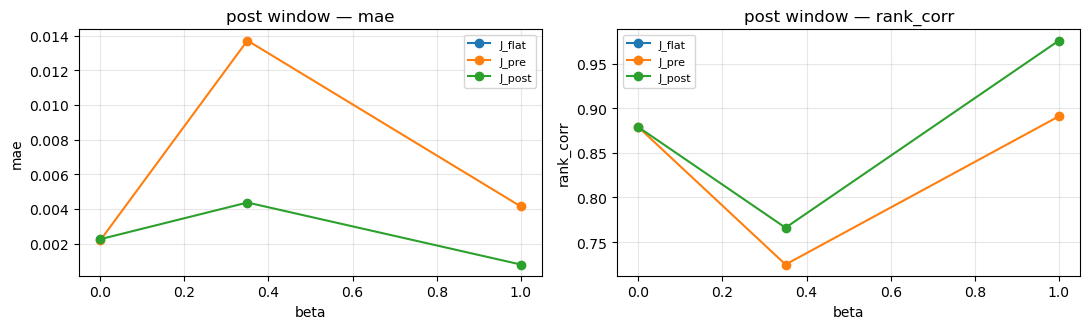

In [13]:
# =====================================================================
# 11. beta ladder
# =====================================================================
bw = WORLDS[WORLDS.arms.str.contains("beta")]
print(f"{len(bw)} worlds in the beta arm: {sorted(bw.beta.unique())}")
if len(bw) < 2:
    print("beta arm incomplete -- P6 unscoreable. Check GATES for exclusions:")
    display(GATES[GATES.arm == "beta"])
else:
    b = R[R.sim_hash.isin(bw.sim_hash) & (R.placement == PLACEMENT)]
    display(b.pivot_table(index=["beta", "method"], columns="window",
                          values="mae").round(3))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    for k, met in enumerate(["mae", "rank_corr"]):
        for m in ["J_flat", "J_pre", "J_post"]:
            s = b[(b.method == m) & (b.window == "post")] \
                .groupby("beta")[met].mean().sort_index()
            ax[k].plot(s.index, s.values, "o-", label=m)
        ax[k].set(xlabel="beta", ylabel=met, title=f"post window — {met}")
        ax[k].legend(fontsize=8); ax[k].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 12. Coupling — the falsification (P5, load-bearing)

With `close_fraction = 1.0` the districts are hydraulically separated, so
mixing ≈ 0. Raw sensors should then **already** recover the truth and
unmixing should show near-zero gain.

If the gain persists on isolated worlds, attributing it to hydraulic mixing
is wrong. This is the single strongest available test that the +0.767 result
means what section 5 says it means, and the baseline cells are exact cache
hits of `jval_s1_oddone` at seed 42, so the contrast is exactly paired.

In [14]:
# =====================================================================
# 12. baseline vs isolated
# =====================================================================
cw = WORLDS[WORLDS.arms.str.contains("coupling")]
ccols = [c for c in ("sim_hash", "variant", "close_fraction",
                     "drift_district") if c in cw.columns]
print(cw[ccols].to_string(index=False) if len(cw)
      else "no coupling worlds pinned")

g = G[(G.window == "pre") & G.sim_hash.isin(cw.sim_hash)] if len(cw) else G.iloc[:0]
if len(g):
    display(g.pivot_table(index=["drift_district", "variant"],
                          values=[MAIN_ARM, "best_free", "gain"]).round(3))
    iso = g.loc[g.variant == "isolated", "gain"]
    bas = g.loc[g.variant == "baseline", "gain"]
    print(f"\nisolated gain {iso.mean():+.3f} (n={len(iso)})   "
          f"baseline gain {bas.mean():+.3f} (n={len(bas)})")
    print("P5 predicts isolated ~ 0. A persistent gain here means the +0.767 "
          "is NOT hydraulic unmixing and the section-5 story needs rewriting.")

    sim_hash  variant  close_fraction drift_district
b472a1a6af0b isolated             1.0     District_A
adce256d7a30 isolated             1.0     District_E
74e5d158e6e7 baseline             0.0     District_A
adfe1b1ae73a baseline             0.0     District_E
fbd240dac636 baseline             0.0     District_E


J_pre  best_free   gain
drift_district variant                          
District_A     baseline  0.806      0.782  0.024
               isolated  0.867     -0.079  0.945
District_E     baseline  0.824      0.812  0.012
               isolated  0.903      0.103  0.800


isolated gain +0.873 (n=2)   baseline gain +0.016 (n=3)
P5 predicts isolated ~ 0. A persistent gain here means the +0.767 is NOT hydraulic unmixing and the section-5 story needs rewriting.


## 13. The pre-registered scoreboard (handoff 7.8)

Written down before the numbers existed, precisely because a post-hoc
selection bug has already bitten once. Every verdict carries its failure
interpretation, so a FAIL is informative rather than merely disappointing.

P5 is the load-bearing one.

In [15]:
# =====================================================================
# 13. score P1..P7
# =====================================================================
SB = J.predictions(R, PR, main_arm=MAIN_ARM, placement=PLACEMENT,
                   noise_floor=FLOOR)
display(SB)
print(SB.verdict.value_counts().to_string())

,P,claim,value,verdict,note
0,P1,pre-window MAE ~ 0.05,0.0029,PASS,"failure implicates the windowing, not the method"
1,P2,transition window worst of three,0.533,PASS,24/45 worlds; failure -> look at the operating...
2,P3,|d rho_hat| non-drifter pairs < 0.02,0.0072,PASS,n=270 pairs; true |d| = 0.0012
3,P4,signed change correct in >=90%,1.0,PASS,n=156 pairs; true-sign agreement 1.000
4,P5,isolated gain ~ 0 while baseline gain > 0,iso +0.873 / base +0.183,FAIL,load-bearing: failure means the gain is not hy...
5,P6,MAE monotone increasing in beta,0.0:0.002 / 0.35:0.011 / 1.0:0.004,FAIL,failure -> the operating point is not the mech...
6,P7,M2 amplitude rank correct,1.0,PASS,n=6 income worlds; std_r=0.001. A negative ans...


verdict
PASS    5
FAIL    2


## 14. The transition prediction (P2)

The transition window is a prediction, not waste. Mid-conversion a district
is internally heterogeneous — which is exactly the **spatially coherent
`node_weights` error** that was the only form of misspecification that
measurably hurt recovery. Predicted signature: recovery dips during
transition and returns afterwards.

Error tracking a known physical cause and then recovering is much stronger
evidence than a flat robustness number.

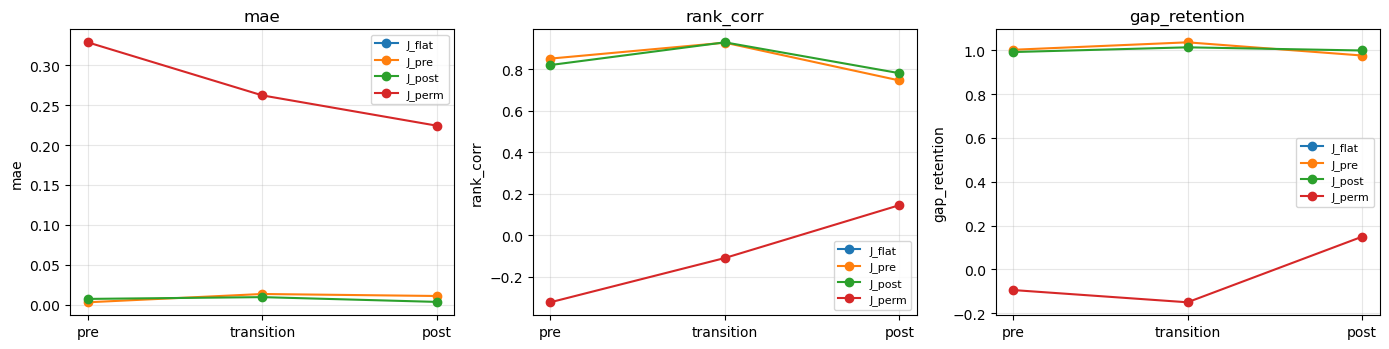

=== per-world window ranking on MAE (P2) ===
transition    24
post          16
pre            5

transition worst in 53.3% of worlds


window,pre,transition,post
count,45.0000,45.0000,45.0000
mean,0.0029,0.0133,0.0108
std,0.0017,0.0117,0.0108
min,0.0008,0.0013,0.0010
25%,0.0014,0.0039,0.0022
50%,0.0019,0.0084,0.0086
75%,0.0044,0.0239,0.0122
max,0.0052,0.0516,0.0357


In [16]:
# =====================================================================
# 14. recovery across the three windows
# =====================================================================
order = ["pre", "transition", "post"]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for k, met in enumerate(["mae", "rank_corr", "gap_retention"]):
    for m in ["J_flat", "J_pre", "J_post", "J_perm"]:
        s = main[main.method == m].groupby("window")[met].mean().reindex(order)
        ax[k].plot(order, s.values, "o-", label=m)
    ax[k].set(title=met, ylabel=met); ax[k].grid(alpha=.3)
    ax[k].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("=== per-world window ranking on MAE (P2) ===")
piv = main[main.method == MAIN_ARM].pivot_table(
    index="sim_hash", columns="window", values="mae")[order]
worst = piv.idxmax(axis=1)
print(worst.value_counts().to_string())
print(f"\ntransition worst in {(worst=='transition').mean():.1%} of worlds")
display(piv.describe().round(4))

## 15. Export

`results.parquet` (M1 + M2 per world × arm × window), `pairs.parquet` (the
pair-level frame P3/P4 are computed from), `truth.parquet`,
`jacobian_diag.parquet`, `gates.csv`, `scoreboard.csv`, and
`pinned_worlds.csv` from §2.

Everything a thesis table needs, reconstructible from the pinned hash list.

In [ ]:
# =====================================================================
# 15. persist
# =====================================================================
files = J.save(OUT, results=R, pairs=PR, truth=TA, jacobian_diag=DG,
               gain_rank=G, gain_mae=GM)
GATES.to_csv(OUT / "gates.csv", index=False)
PD.to_csv(OUT / "probe_diag.csv", index=False)
if len(SKIPPED):
    SKIPPED.to_csv(OUT / "skipped_worlds.csv", index=False)
SB.to_csv(OUT / "scoreboard.csv", index=False)
print(files + ["gates.csv", "scoreboard.csv", "pinned_worlds.csv",
               "probe_diag.csv"] + (["skipped_worlds.csv"] if len(SKIPPED) else []))
print(f"-> {OUT}")